### Import

In [23]:
import os
import numpy as np
import sys
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as patches
import spectral.io.aviris as aviris
import colour
from PIL import Image
from sklearn.datasets import make_moons, make_circles, make_classification
from scipy.stats import multivariate_normal as mnorm
from scipy import ndimage
from matplotlib import cm
from matplotlib.colors import LogNorm
from mpl_toolkits import mplot3d
from skimage import io, color
from matplotlib.collections import PatchCollection
from matplotlib.patches import Rectangle
from scipy.spatial.distance import pdist
from scipy.spatial.distance import cdist
from scipy.spatial.distance import squareform
from sklearn import datasets
from colour.plotting import *
from sklearn.cluster import KMeans
from sklearn.cluster import DBSCAN
from sklearn.mixture import GaussianMixture
from sklearn.metrics import homogeneity_score
from sklearn.metrics import completeness_score
from sklearn.metrics import v_measure_score
from sklearn.metrics import adjusted_rand_score
from sklearn.metrics import adjusted_mutual_info_score
from sklearn.metrics import silhouette_score

### Fonts

In [24]:
csfont = {'fontname':'Georgia'}
hfont = {'fontname':'Helvetica'}

### Parameters

In [25]:
resolution = 9
eps = 0.2
minPts = 5
noise = 0.1
no_points_0 = 500
no_points_1 = 500
np.random.seed(400)

### Spherical Data

In [26]:
mu0 = np.array([-1,0])
mu1 = np.array([+1,0])
sigma0 = np.array([[1, 0], [0, 1]]) * 0.2
sigma1 = np.array([[1, 0], [0, 1]]) * 0.2
distr0 = mnorm(mu0,sigma0)
distr1 = mnorm(mu1,sigma1)
x0 = distr0.rvs(no_points_0)
x1 = distr1.rvs(no_points_1)
XS = np.vstack((x0,x1))

### Oriented Data

In [40]:
mu0 = np.array([-0.7,0])
mu1 = np.array([+0.7,0])
sigma0 = np.array([[0.75, 0.75], [0.75, 1]]) * 0.3
sigma1 = np.array([[0.75, 0.75], [0.75, 1]]) * 0.3
distr0 = mnorm(mu0,sigma0)
distr1 = mnorm(mu1,sigma1)
x0 = distr0.rvs(no_points_0)
x1 = distr1.rvs(no_points_1)
XO = np.vstack((x0,x1))

### Half Moon Data

In [41]:
XM,ym = make_moons(noise=0.05, random_state=400, n_samples=no_points_1*2)
XM[:,0] = XM[:,0] - np.mean(XM[:,0],axis=0)
XM[:,1] = XM[:,1] - np.mean(XM[:,1],axis=0)
XM = XM * 1.5
y0 = np.where(ym == 0)[0]
y1 = np.where(ym == 1)[0]

### Algorithms

In [42]:
dbs = DBSCAN(eps=0.2, min_samples=15).fit(XS)
dbo = DBSCAN(eps=0.2, min_samples=15).fit(XO)
dbm = DBSCAN(eps=0.2, min_samples=15).fit(XM)

kmeanss = KMeans(n_clusters=2, random_state=0).fit(XS)
kmeanso = KMeans(n_clusters=2, random_state=0).fit(XO)
kmeansm = KMeans(n_clusters=2, random_state=0).fit(XM)

gmms = GaussianMixture(n_components=2, covariance_type="full").fit(XS)
gmmo = GaussianMixture(n_components=2, covariance_type="full").fit(XO)    
gmmm = GaussianMixture(n_components=2, covariance_type="full").fit(XM)
gmms.labels = gmms.predict(XS)
gmmo.labels = gmmo.predict(XO)
gmmm.labels = gmmm.predict(XM)

### Plot Ground Thruth

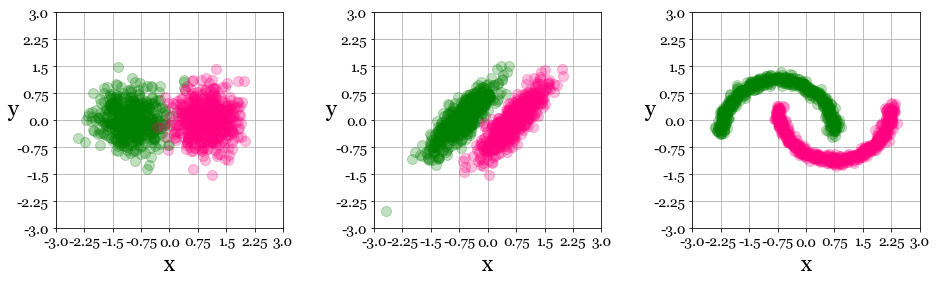

In [43]:
plt.figure(figsize=(12,3));
plt.subplots_adjust(left=0.0,bottom=0.0, right=1.0, top=1.0, wspace=0.4, hspace=0.4)
plt.subplot(1,3,1)
plt.scatter(XS[:500,0],XS[:500,1],alpha=0.25,color=(0,0.5,0.0),s=100,zorder=100)
plt.scatter(XS[500:,0],XS[500:,1],alpha=0.25,color=(1.0,0,0.5),s=100,zorder=100)
plt.xlabel('x',fontsize=22,**csfont);
plt.ylabel('y',fontsize=22,**csfont,rotation=0);
plt.yticks(np.linspace(-3,3,resolution),labels=np.linspace(-3,3,resolution),fontsize=14,**csfont);
plt.xticks(np.linspace(-3,3,resolution),labels=np.linspace(-3,3,resolution),fontsize=14,**csfont);
plt.grid()
plt.axis((-3,3,-3,3));
plt.subplot(1,3,2)
plt.scatter(XO[:500,0],XO[:500,1],alpha=0.25,color=(0,0.5,0.0),s=100,zorder=100)
plt.scatter(XO[500:,0],XO[500:,1],alpha=0.25,color=(1.0,0,0.5),s=100,zorder=100)
plt.xlabel('x',fontsize=22,**csfont);
plt.ylabel('y',fontsize=22,**csfont,rotation=0);
plt.yticks(np.linspace(-3,3,resolution),labels=np.linspace(-3,3,resolution),fontsize=14,**csfont);
plt.xticks(np.linspace(-3,3,resolution),labels=np.linspace(-3,3,resolution),fontsize=14,**csfont);
plt.grid()
plt.axis((-3,3,-3,3));
plt.subplot(1,3,3)
plt.scatter(XM[y0,0],XM[y0,1],alpha=0.25,color=(0,0.5,0.0),s=100,zorder=100)
plt.scatter(XM[y1,0],XM[y1,1],alpha=0.25,color=(1.0,0,0.5),s=100,zorder=100)
plt.xlabel('x',fontsize=22,**csfont);
plt.ylabel('y',fontsize=22,**csfont,rotation=0);
plt.yticks(np.linspace(-3,3,resolution),labels=np.linspace(-3,3,resolution),fontsize=14,**csfont);
plt.xticks(np.linspace(-3,3,resolution),labels=np.linspace(-3,3,resolution),fontsize=14,**csfont);
plt.grid()
plt.axis((-3,3,-3,3));
plt.savefig('../../assets/figures/017/kmeans-limitations-groundthruth.png',dpi=300,bbox_inches="tight")

### Plot DBScan

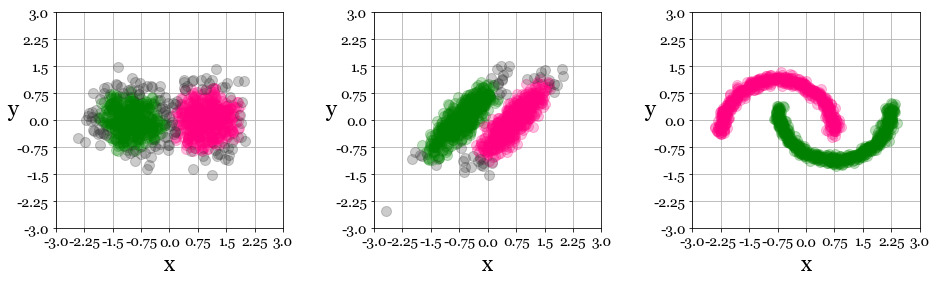

In [44]:
plt.figure(figsize=(12,3));
plt.subplots_adjust(left=0.0,bottom=0.0, right=1.0, top=1.0, wspace=0.4, hspace=0.4)
plt.subplot(1,3,1)
idx0 = np.where(dbs.labels_ == 0)[0]
idx1 = np.where(dbs.labels_ == 1)[0]
idx2 = np.where(dbs.labels_ == -1)[0]
plt.scatter(XS[idx0,0],XS[idx0,1],alpha=0.25,color=(0,0.5,0.0),s=100,zorder=100)
plt.scatter(XS[idx1,0],XS[idx1,1],alpha=0.25,color=(1.0,0,0.5),s=100,zorder=100)
plt.scatter(XS[idx2,0],XS[idx2,1],alpha=0.25,color=(0.2,0.2,0.2),s=100,zorder=100)
plt.xlabel('x',fontsize=22,**csfont);
plt.ylabel('y',fontsize=22,**csfont,rotation=0);
plt.yticks(np.linspace(-3,3,resolution),labels=np.linspace(-3,3,resolution),fontsize=14,**csfont);
plt.xticks(np.linspace(-3,3,resolution),labels=np.linspace(-3,3,resolution),fontsize=14,**csfont);
plt.grid()
plt.axis((-3,3,-3,3));

plt.subplot(1,3,2)
idx0 = np.where(dbo.labels_ == 0)[0]
idx1 = np.where(dbo.labels_ == 1)[0]
idx2 = np.where(dbo.labels_ == -1)[0]
plt.scatter(XO[idx0,0],XO[idx0,1],alpha=0.25,color=(0,0.5,0.0),s=100,zorder=100)
plt.scatter(XO[idx1,0],XO[idx1,1],alpha=0.25,color=(1.0,0,0.5),s=100,zorder=100)
plt.scatter(XO[idx2,0],XO[idx2,1],alpha=0.25,color=(0.2,0.2,0.2),s=100,zorder=100)
plt.xlabel('x',fontsize=22,**csfont);
plt.ylabel('y',fontsize=22,**csfont,rotation=0);
plt.yticks(np.linspace(-3,3,resolution),labels=np.linspace(-3,3,resolution),fontsize=14,**csfont);
plt.xticks(np.linspace(-3,3,resolution),labels=np.linspace(-3,3,resolution),fontsize=14,**csfont);
plt.grid()
plt.axis((-3,3,-3,3));


plt.subplot(1,3,3)
idx0 = np.where(dbm.labels_ == 0)[0]
idx1 = np.where(dbm.labels_ == 1)[0]
idx2 = np.where(dbm.labels_ == -1)[0]
plt.scatter(XM[idx0,0],XM[idx0,1],alpha=0.25,color=(0,0.5,0.0),s=100,zorder=100)
plt.scatter(XM[idx1,0],XM[idx1,1],alpha=0.25,color=(1.0,0,0.5),s=100,zorder=100)
plt.scatter(XM[idx2,0],XM[idx2,1],alpha=0.25,color=(0.2,0.2,0.2),s=100,zorder=100)
plt.xlabel('x',fontsize=22,**csfont);
plt.ylabel('y',fontsize=22,**csfont,rotation=0);
plt.yticks(np.linspace(-3,3,resolution),labels=np.linspace(-3,3,resolution),fontsize=14,**csfont);
plt.xticks(np.linspace(-3,3,resolution),labels=np.linspace(-3,3,resolution),fontsize=14,**csfont);
plt.grid()
plt.axis((-3,3,-3,3));
plt.savefig('../../assets/figures/017/kmeans-limitations-dbscan.png',dpi=300,bbox_inches="tight")

### Plot K-means

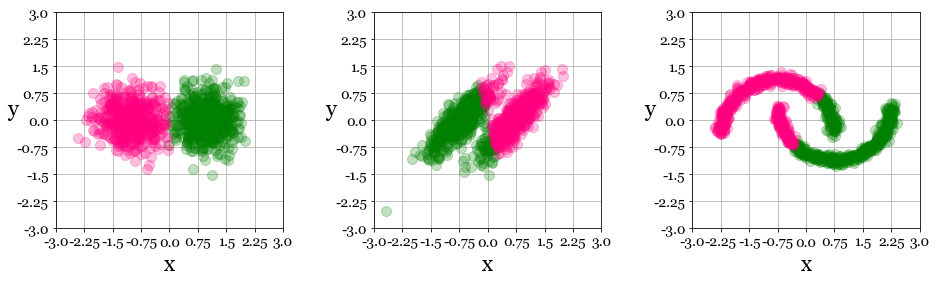

In [45]:
plt.figure(figsize=(12,3));
plt.subplots_adjust(left=0.0,bottom=0.0, right=1.0, top=1.0, wspace=0.4, hspace=0.4)
plt.subplot(1,3,1)
idx0 = np.where(kmeanss.labels_ == 0)[0]
idx1 = np.where(kmeanss.labels_ == 1)[0]
idx2 = np.where(kmeanss.labels_ == -1)[0]
plt.scatter(XS[idx0,0],XS[idx0,1],alpha=0.25,color=(0,0.5,0.0),s=100,zorder=100)
plt.scatter(XS[idx1,0],XS[idx1,1],alpha=0.25,color=(1.0,0,0.5),s=100,zorder=100)
plt.scatter(XS[idx2,0],XS[idx2,1],alpha=0.25,color=(0.2,0.2,0.2),s=100,zorder=100)
plt.xlabel('x',fontsize=22,**csfont);
plt.ylabel('y',fontsize=22,**csfont,rotation=0);
plt.yticks(np.linspace(-3,3,resolution),labels=np.linspace(-3,3,resolution),fontsize=14,**csfont);
plt.xticks(np.linspace(-3,3,resolution),labels=np.linspace(-3,3,resolution),fontsize=14,**csfont);
plt.grid()
plt.axis((-3,3,-3,3));

plt.subplot(1,3,2)
idx0 = np.where(kmeanso.labels_ == 0)[0]
idx1 = np.where(kmeanso.labels_ == 1)[0]
idx2 = np.where(kmeanso.labels_ == -1)[0]
plt.scatter(XO[idx0,0],XO[idx0,1],alpha=0.25,color=(0,0.5,0.0),s=100,zorder=100)
plt.scatter(XO[idx1,0],XO[idx1,1],alpha=0.25,color=(1.0,0,0.5),s=100,zorder=100)
plt.scatter(XO[idx2,0],XO[idx2,1],alpha=0.25,color=(0.2,0.2,0.2),s=100,zorder=100)
plt.xlabel('x',fontsize=22,**csfont);
plt.ylabel('y',fontsize=22,**csfont,rotation=0);
plt.yticks(np.linspace(-3,3,resolution),labels=np.linspace(-3,3,resolution),fontsize=14,**csfont);
plt.xticks(np.linspace(-3,3,resolution),labels=np.linspace(-3,3,resolution),fontsize=14,**csfont);
plt.grid()
plt.axis((-3,3,-3,3));

plt.subplot(1,3,3)
idx0 = np.where(kmeansm.labels_ == 0)[0]
idx1 = np.where(kmeansm.labels_ == 1)[0]
idx2 = np.where(kmeansm.labels_ == -1)[0]
plt.scatter(XM[idx0,0],XM[idx0,1],alpha=0.25,color=(0,0.5,0.0),s=100,zorder=100)
plt.scatter(XM[idx1,0],XM[idx1,1],alpha=0.25,color=(1.0,0,0.5),s=100,zorder=100)
plt.scatter(XM[idx2,0],XM[idx2,1],alpha=0.25,color=(0.2,0.2,0.2),s=100,zorder=100)
plt.xlabel('x',fontsize=22,**csfont);
plt.ylabel('y',fontsize=22,**csfont,rotation=0);
plt.yticks(np.linspace(-3,3,resolution),labels=np.linspace(-3,3,resolution),fontsize=14,**csfont);
plt.xticks(np.linspace(-3,3,resolution),labels=np.linspace(-3,3,resolution),fontsize=14,**csfont);
plt.grid()
plt.axis((-3,3,-3,3));
plt.savefig('../../assets/figures/017/kmeans-limitations-kmeans.png',dpi=300,bbox_inches="tight")

### Plot GMM

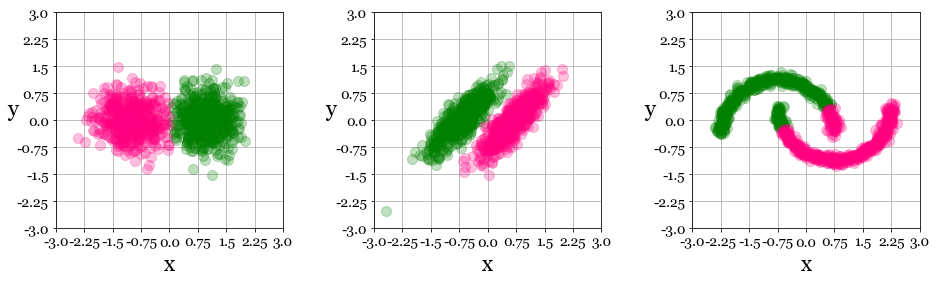

In [46]:
plt.figure(figsize=(12,3));
plt.subplots_adjust(left=0.0,bottom=0.0, right=1.0, top=1.0, wspace=0.4, hspace=0.4)
plt.subplot(1,3,1)
idx0 = np.where(gmms.labels == 0)[0]
idx1 = np.where(gmms.labels == 1)[0]
idx2 = np.where(gmms.labels == -1)[0]
plt.scatter(XS[idx0,0],XS[idx0,1],alpha=0.25,color=(0,0.5,0.0),s=100,zorder=100)
plt.scatter(XS[idx1,0],XS[idx1,1],alpha=0.25,color=(1.0,0,0.5),s=100,zorder=100)
plt.scatter(XS[idx2,0],XS[idx2,1],alpha=0.25,color=(0.2,0.2,0.2),s=100,zorder=100)
plt.xlabel('x',fontsize=22,**csfont);
plt.ylabel('y',fontsize=22,**csfont,rotation=0);
plt.yticks(np.linspace(-3,3,resolution),labels=np.linspace(-3,3,resolution),fontsize=14,**csfont);
plt.xticks(np.linspace(-3,3,resolution),labels=np.linspace(-3,3,resolution),fontsize=14,**csfont);
plt.grid()
plt.axis((-3,3,-3,3));

plt.subplot(1,3,2)
idx0 = np.where(gmmo.labels == 0)[0]
idx1 = np.where(gmmo.labels == 1)[0]
idx2 = np.where(gmmo.labels == -1)[0]
plt.scatter(XO[idx0,0],XO[idx0,1],alpha=0.25,color=(0,0.5,0.0),s=100,zorder=100)
plt.scatter(XO[idx1,0],XO[idx1,1],alpha=0.25,color=(1.0,0,0.5),s=100,zorder=100)
plt.scatter(XO[idx2,0],XO[idx2,1],alpha=0.25,color=(0.2,0.2,0.2),s=100,zorder=100)
plt.xlabel('x',fontsize=22,**csfont);
plt.ylabel('y',fontsize=22,**csfont,rotation=0);
plt.yticks(np.linspace(-3,3,resolution),labels=np.linspace(-3,3,resolution),fontsize=14,**csfont);
plt.xticks(np.linspace(-3,3,resolution),labels=np.linspace(-3,3,resolution),fontsize=14,**csfont);
plt.grid()
plt.axis((-3,3,-3,3));

plt.subplot(1,3,3)
idx0 = np.where(gmmm.labels == 0)[0]
idx1 = np.where(gmmm.labels == 1)[0]
idx2 = np.where(gmmm.labels == -1)[0]
plt.scatter(XM[idx0,0],XM[idx0,1],alpha=0.25,color=(0,0.5,0.0),s=100,zorder=100)
plt.scatter(XM[idx1,0],XM[idx1,1],alpha=0.25,color=(1.0,0,0.5),s=100,zorder=100)
plt.scatter(XM[idx2,0],XM[idx2,1],alpha=0.25,color=(0.2,0.2,0.2),s=100,zorder=100)
plt.xlabel('x',fontsize=22,**csfont);
plt.ylabel('y',fontsize=22,**csfont,rotation=0);
plt.yticks(np.linspace(-3,3,resolution),labels=np.linspace(-3,3,resolution),fontsize=14,**csfont);
plt.xticks(np.linspace(-3,3,resolution),labels=np.linspace(-3,3,resolution),fontsize=14,**csfont);
plt.grid()
plt.axis((-3,3,-3,3));
plt.savefig('../../assets/figures/017/kmeans-limitations-gmm.png',dpi=300,bbox_inches="tight")